In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    "nifty_50_comp_price_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794525,361.062561,1403.106934,1690.746338,745.586914,2599.727783,413.532196,29.713722,433.316498,449.420258,...,201.816833,406.074036,306.714355,38.457085,1841.149292,602.617493,1132.704956,526.402710,3942.765625,113.709183
2020-01-02,209.111359,366.321014,1470.294067,1688.342407,753.802612,2575.711670,414.973724,30.603800,435.132721,447.153778,...,204.996552,406.681732,306.240814,39.862995,1832.697754,605.740845,1133.538574,538.030945,4117.158691,113.984634
2020-01-03,206.240067,365.699554,1461.883301,1651.334717,739.860840,2535.314453,409.833008,29.951080,435.037109,443.801361,...,204.899414,415.704620,301.363312,39.768440,1869.222168,612.897095,1117.942017,532.614319,4092.329102,115.269989
2020-01-06,197.576599,363.500580,1438.667969,1609.613159,720.242676,2506.924316,390.604340,28.764307,429.827362,440.779388,...,197.338669,411.356781,295.586090,38.909275,1869.051880,609.180664,1136.481201,526.700928,4032.095703,115.751999
2020-01-07,202.032074,367.898529,1454.603760,1625.877197,722.732300,2507.171875,391.674469,28.586292,425.477966,442.526489,...,198.601746,417.387543,298.237915,39.143593,1873.639404,614.478577,1137.805542,529.682434,4114.540039,117.152138


In [10]:
returns = data.pct_change()

corr_matrix = returns.corr()

In [14]:
pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        stock1 = corr_matrix.columns[i]
        stock2 = corr_matrix.columns[j]

        corr = corr_matrix.iloc[i, j]

        if corr > 0.60:

            pairs.append(
                [stock1, stock2, corr]
            )

pairs_df = pd.DataFrame(
    pairs,
    columns=[
        "Stock1",
        "Stock2",
        "Correlation"
    ]
)

pairs_df.sort_values(
    "Correlation",
    ascending=False
).head(20)

,Stock1,Stock2,Correlation
15,JSWSTEEL.NS,TATASTEEL.NS,0.777276
10,HINDALCO.NS,TATASTEEL.NS,0.729698
1,AXISBANK.NS,ICICIBANK.NS,0.728239
12,INFY.NS,TCS.NS,0.723561
0,ADANIENT.NS,ADANIPORTS.NS,0.702799
4,HCLTECH.NS,INFY.NS,0.699486
9,HINDALCO.NS,JSWSTEEL.NS,0.681248
3,GRASIM.NS,ULTRACEMCO.NS,0.662706
5,HCLTECH.NS,TCS.NS,0.661623
13,INFY.NS,TECHM.NS,0.656937


In [16]:
from statsmodels.tsa.stattools import coint

results = []

for _, row in pairs_df.iterrows():

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    score, pvalue, _ = coint(
        data[stock1],
        data[stock2]
    )

    results.append([
        stock1,
        stock2,
        row["Correlation"],
        pvalue
    ])

cointegration_df = pd.DataFrame(
    results,
    columns=[
        "Stock1",
        "Stock2",
        "Correlation",
        "P_Value"
    ]
)

cointegration_df = cointegration_df.sort_values(
    "P_Value"
)

cointegration_df

,Stock1,Stock2,Correlation,P_Value
2,AXISBANK.NS,SBIN.NS,0.620640,0.017487
10,HINDALCO.NS,TATASTEEL.NS,0.729698,0.085806
9,HINDALCO.NS,JSWSTEEL.NS,0.681248,0.099910
15,JSWSTEEL.NS,TATASTEEL.NS,0.777276,0.102358
3,GRASIM.NS,ULTRACEMCO.NS,0.662706,0.116135
7,HDFCBANK.NS,ICICIBANK.NS,0.635621,0.152176
1,AXISBANK.NS,ICICIBANK.NS,0.728239,0.154299
14,INFY.NS,WIPRO.NS,0.630629,0.169241
12,INFY.NS,TCS.NS,0.723561,0.208956
8,HDFCLIFE.NS,SBILIFE.NS,0.637586,0.348349


In [17]:
import statsmodels.api as sm

y = data["AXISBANK.NS"]

x = data["SBIN.NS"]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

beta = model.params["SBIN.NS"]

print("Beta:", beta)

Beta: 1.0034328737521083


In [18]:
spread = (
    data["AXISBANK.NS"]
    - beta * data["SBIN.NS"]
)

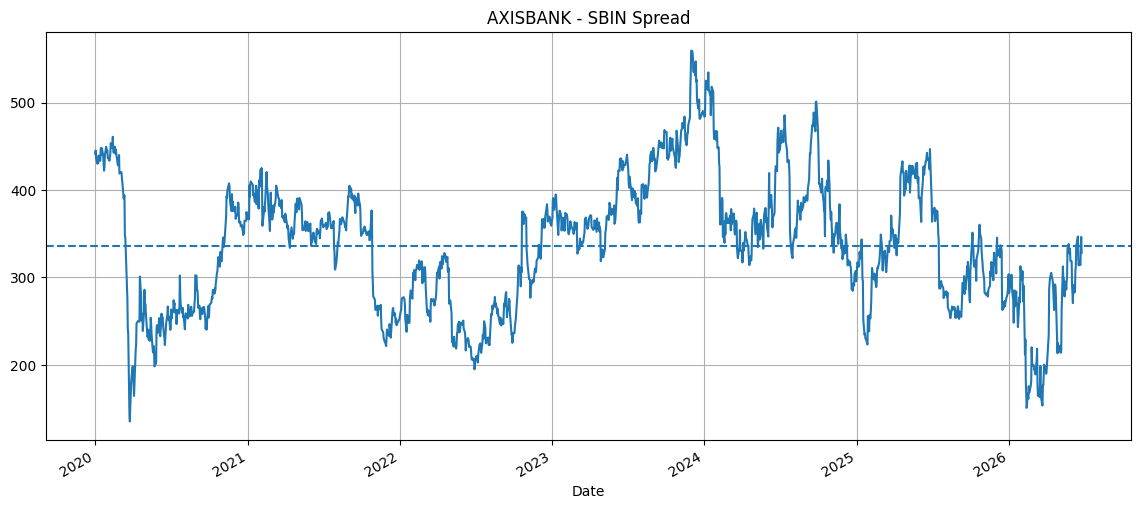

In [19]:
plt.figure(figsize=(14,6))

spread.plot()

plt.axhline(
    spread.mean(),
    linestyle="--"
)

plt.title(
    "AXISBANK - SBIN Spread"
)

plt.grid(True)

plt.show()

In [20]:
zscore = (
    spread - spread.mean()
) / spread.std()

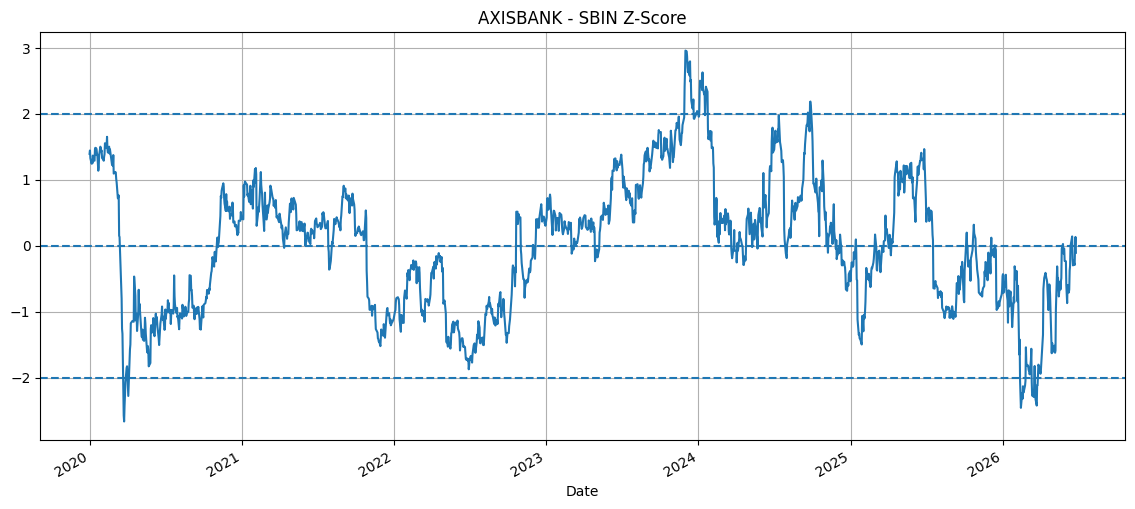

In [21]:
plt.figure(figsize=(14,6))

zscore.plot()

plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.axhline(0, linestyle="--")

plt.title("AXISBANK - SBIN Z-Score")

plt.grid(True)

plt.show()

In [ ]:
print("Z > 2 occurrences:",
      (zscore > 2).sum())

print("Z < -2 occurrences:",
      (zscore < -2).sum())

Z > 2 occurrences: 34
Z < -2 occurrences: 26


In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(spread)

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -3.7146515829927917
P-value: 0.003911723340547947


In [25]:
position = pd.Series(
    0,
    index=zscore.index
)

current_position = 0

for i in range(len(zscore)):

    z = zscore.iloc[i]

    if current_position == 0:

        if z > 2:
            current_position = -1

        elif z < -2:
            current_position = 1

    elif current_position == 1:

        if z >= 0:
            current_position = 0

    elif current_position == -1:

        if z <= 0:
            current_position = 0

    position.iloc[i] = current_position

In [26]:
axis_ret = data["AXISBANK.NS"].pct_change()

sbin_ret = data["SBIN.NS"].pct_change()

spread_ret = (
    axis_ret
    - beta * sbin_ret
)

strategy_ret = (
    position.shift(1)
    * spread_ret
)

In [27]:
print(
    "Days in Trade:",
    (position != 0).sum()
)

print(
    "Long Days:",
    (position == 1).sum()
)

print(
    "Short Days:",
    (position == -1).sum()
)

Days in Trade: 327
Long Days: 221
Short Days: 106


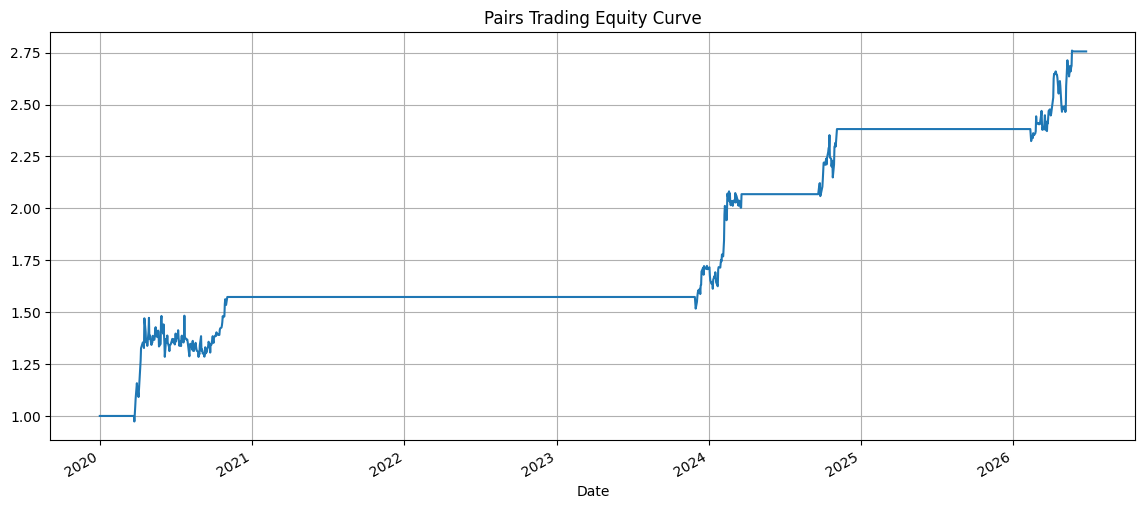

In [28]:
equity_curve = (
    1 + strategy_ret.fillna(0)
).cumprod()

plt.figure(figsize=(14,6))

equity_curve.plot()

plt.title(
    "Pairs Trading Equity Curve"
)

plt.grid(True)

plt.show()

In [29]:
trades = (
    position.diff().abs() > 0
).sum()

print("Position Changes:", trades)

entries = (
    (position.shift(1) == 0)
    & (position != 0)
).sum()

print("Entries:", entries)

Position Changes: 8
Entries: 4


In [30]:
trade_log = []

current_position = 0
entry_date = None
entry_equity = None

equity_curve = (
    1 + strategy_ret.fillna(0)
).cumprod()